# Task 1
Перевірте, як поліноміальні ознаки впливають на якість моделі:
Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).

* Побудуйте модель лінійної регресії на вихідних даних.
* Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
* Навчіть модель на розширеному наборі ознак.
* Побудуйте графік: вихідні точки та лінії передбачень для обох моделей.

In [1]:
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=200, n_features=1, noise=150, random_state=42)
print(X[:5], y[:5])

[[ 1.85227818]
 [ 0.47359243]
 [-1.23086432]
 [ 0.62566735]
 [-0.07201012]] [-28.11687095 172.43296329 127.51212144  99.21599695 -25.57979614]


In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
model1 = LinearRegression()
model1.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [6]:
model2 = make_pipeline(PolynomialFeatures(degree =2), LinearRegression())

In [7]:
model2.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [8]:
import matplotlib.pyplot as plt

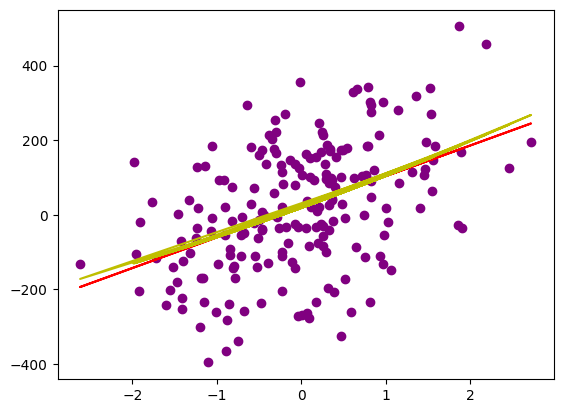

In [9]:
_, ax = plt.subplots()
ax.scatter(X, y, color='purple')
ax.plot(X, model1.predict(X), 'r-')
ax.plot(X, model2.predict(X), 'y-')
plt.show()

# Task 2
Порівняйте моделі з різним ступенем полінома і проаналізуйте перенавчання:
Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20).

* Побудуйте моделі для ступенів полінома: 2, 5, 10.
* Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
* Для кожної моделі обчисліть R² на навчальній і тестовій вибірках.
* Оформіть результати в таблиці:

In [10]:
X2, y2 = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)

In [11]:
from sklearn.model_selection import train_test_split
degrees = [2, 5, 10]
models = [make_pipeline(PolynomialFeatures(degree=degree), LinearRegression()) for degree in degrees]
xtrain, xtest, ytrain, ytest = train_test_split(
    X2,
    y2,
    test_size = 0.2,
    random_state = 42,
)

In [12]:
for model in models:
    model.fit(xtrain, ytrain)

from IPython.display import Markdown as md
import sklearn.metrics as sm

In [13]:
md("|Polynom degree|Train R^2|Test R^2|\n|-|-|-|\n" + '\n'.join(f'|{degrees[i]}|{1 - abs(sm.r2_score(ytrain, models[i].predict(xtrain)))}|{1 - abs(sm.r2_score(ytest, models[i].predict(xtest)))}|' for i in range(len(degrees))))

|Polynom degree|Train R^2|Test R^2|
|-|-|-|
|2|0.060024063204569655|0.05504586763666841|
|5|0.05840879647459152|0.11386687620529401|
|10|0.05710277569672384|-30.840955119114362|

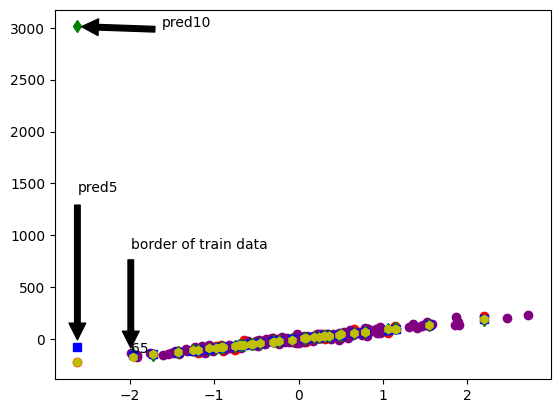

In [15]:
pred2 = models[0].predict(xtest)
pred5 = models[1].predict(xtest)
pred10 = models[2].predict(xtest)
_, ax = plt.subplots()
ax.plot(xtest, ytest, 'ro')
ax.plot(xtrain, ytrain, 'o', color='purple')
ax.plot(xtest, pred10, 'gd')
ax.plot(xtest, pred5, 'bs')
ax.plot(xtest, pred2, 'yh')
p = 15
ax.annotate('pred10', (xtest[p][0], pred10[p]), (xtest[p][0] + 1, pred10[p]), arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('pred5', (xtest[p][0], pred5[p]), (xtest[p][0], pred5[p] + 1500), arrowprops=dict(facecolor='black', shrink=0.05))
# for p in range(len(ytest)):
p = 65
ax.annotate(str(p), (xtrain[p][0], ytrain[p]))
ax.annotate('border of train data', (xtrain[p][0], ytrain[p]), (xtrain[p][0], ytrain[p] + 1000), arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()